Text(0, 0.5, '不纯度')

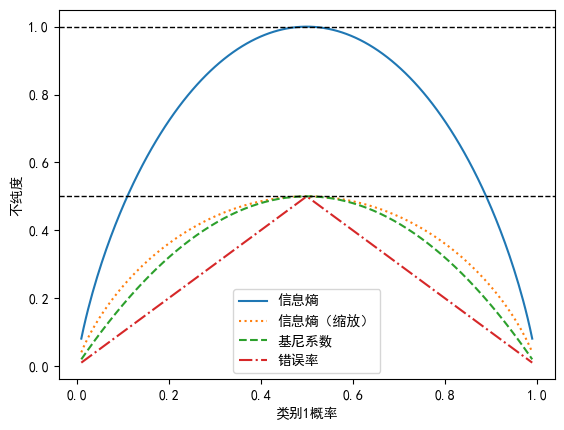

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def gini(p):
    return 1 - np.sum(p ** 2, axis=1)

def entropy(p):
    return -np.sum(p * np.log2(p), axis=1)

def error(p):
    return 1 - np.max(p, axis=1)

p = np.linspace(0.01, 0.99, 200)
parray = np.array([p, 1 - p]).T
en = entropy(parray)
en2 = en * 0.5
g = gini(parray)
err = error(parray)

fig = plt.figure()
for i, lab, ls in zip([en, en2, g, err], ["信息熵", "信息熵（缩放）", "基尼系数", "错误率"],
                 ["-", ":", "--", "-."]):
    plt.plot(p, i, label=lab, ls=ls)
plt.legend()
plt.axhline(y=0.5, linewidth=1, color="k", ls="--")
plt.axhline(y=1, linewidth=1, color="k", ls="--")
plt.xlabel("类别1概率")
plt.ylabel("不纯度")

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X[:, :2], y, test_size=0.25, random_state=0)
# 对于决策树，参数的默认值都是不限制树的生长，因此，决策树在默认的超参数下，具有很好的拟合能力，但是
# 也容易产生过拟合。
# criterion：不纯度度量标准。可选值：entropy(信息熵)，gini（基尼系数），默认值为gini。
# splitter：选择切分阈值的方式。可选值：best（选择最佳的切分阈值）与random（随机生成阈值，然后在随机阈值中，选择最佳的阈值）。
#           默认为best。
# max_depth：最大深度，默认值为None（不限制最大深度）。
# min_samples_split：最小分裂的样本数量，默认值为2。
# min_samples_leaf：叶子节点最少包含的样本数量，默认值为1。
# max_features：候选最大特征数量，默认值为None，表示候选特征为所有特征。
# random_state：随机种子。
# max_leaf_nodes：最大叶子节点数量，默认值为None，表示不限制叶子节点数量。
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

0.9375
0.6578947368421053


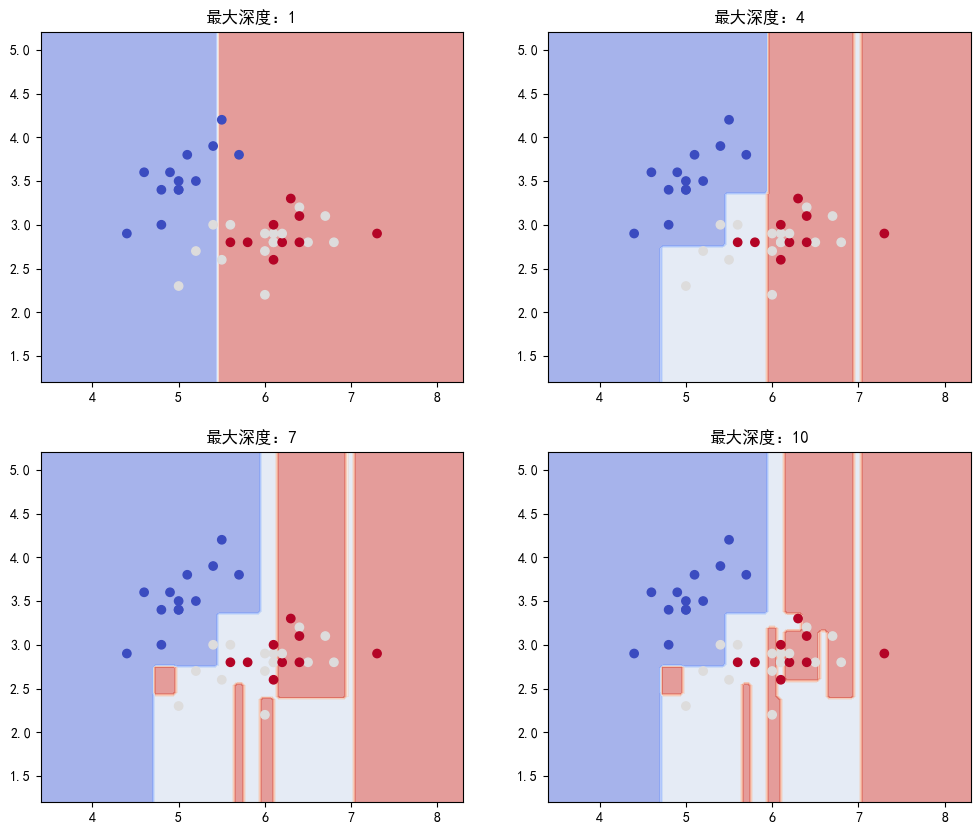

In [3]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(12, 10))
for index, depth in enumerate([1, 4, 7, 10], start=1):
    ax = plt.subplot(2, 2, index)
    plt.title(f"最大深度：{depth}")
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    tree.fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(tree, X_test, response_method="predict", cmap=plt.cm.coolwarm,
                    alpha=0.5, ax=ax)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm)

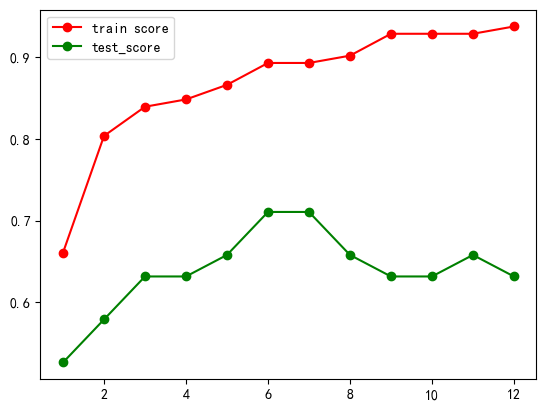

In [4]:
train_score = []
test_score = []
for depth in range(1, 13):
    tree = DecisionTreeClassifier(random_state=0, max_depth=depth)
    tree.fit(X_train, y_train)
    train_score.append(tree.score(X_train, y_train))
    test_score.append(tree.score(X_test, y_test))
plt.plot(range(1, 13), train_score, c="r", label="train score", marker="o")
plt.plot(range(1, 13), test_score, c="g", label="test_score", marker="o")
plt.legend()

In [5]:
# 提供搜索最佳超参数组合的功能。我们只需要提供候选超参数的值即可。
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier()
# estimator：需要进行超参数调整的模型。
# param_grid：提供每个超参数的候选值。GridSearchCV会生成所有超参数的笛卡尔积组合。
#            可以提供两种格式：字典类型（key指定超参数名，value指定所有该超参数的候选值）或包含字典的列表。
# scoring：指定交叉验证，评估的指标。
# cv：交叉验证的折数。
# verbose：该值越大，显示信息越详细。
# n_jobs：并行执行的任务数。-1表示尽计算机最大并行数来执行任务
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [4, 7, 10, None],
    "min_samples_split": [2, 5, 7, 10],
    "min_samples_leaf": [1, 3, 5, 7],
    "max_features": [1, None]
}
gs = GridSearchCV(estimator=tree, param_grid=param_grid, scoring="accuracy", cv=5, verbose=3, n_jobs=-1)
gs.fit(X_train, y_train)
# 最好超参数训练的模型。
print(gs.best_estimator_)
# 交叉验证上，表现最好的超参数组合。
print(gs.best_params_)
# 最好超参数在验证集上的评估得分。
print(gs.best_score_)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_split=7,
                       splitter='random')
{'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 7, 'splitter': 'random'}
0.7956521739130435


In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=5000, n_features=10, random_state=23, noise=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=33)
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

param_grid = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": [4, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 7],
    "max_features": [5, None]
}
gs = GridSearchCV(estimator=tree, param_grid=param_grid, scoring="r2", cv=5, verbose=3, n_jobs=-1)
gs.fit(X_train, y_train)
# 最好超参数训练的模型。
print(gs.best_estimator_)
# 交叉验证上，表现最好的超参数组合。
print(gs.best_params_)
# 最好超参数在验证集上的评估得分。
print(gs.best_score_)
gs.score(X_test, y_test)

1.0
0.5640040513989042
Fitting 5 folds for each of 96 candidates, totalling 480 fits
DecisionTreeRegressor(max_features=5, min_samples_leaf=7, min_samples_split=5)
{'criterion': 'squared_error', 'max_depth': None, 'max_features': 5, 'min_samples_leaf': 7, 'min_samples_split': 5, 'splitter': 'best'}
0.611731351253425


0.5868343472820503

1.0
0.9736842105263158
digraph Tree {
node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
edge [fontname="helvetica"] ;
0 [label="花瓣宽 <= 0.8\ngini = 0.665\nsamples = 112\nvalue = [37, 34, 41]\nclass = virginica", fillcolor="#f8f4fe"] ;
1 [label="gini = 0.0\nsamples = 37\nvalue = [37, 0, 0]\nclass = setosa", fillcolor="#e58139"] ;
0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;
2 [label="花瓣长 <= 4.95\ngini = 0.496\nsamples = 75\nvalue = [0, 34, 41]\nclass = virginica", fillcolor="#e9ddfb"] ;
0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;
3 [label="花瓣宽 <= 1.65\ngini = 0.153\nsamples = 36\nvalue = [0, 33, 3]\nclass = versicolor", fillcolor="#4be78c"] ;
2 -> 3 ;
4 [label="gini = 0.0\nsamples = 32\nvalue = [0, 32, 0]\nclass = versicolor", fillcolor="#39e581"] ;
3 -> 4 ;
5 [label="花萼宽 <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica", fillcolor="#ab7bee"] ;
3 -> 5 ;
6 [label="gini = 0.0\nsamples = 3\nvalue = [0

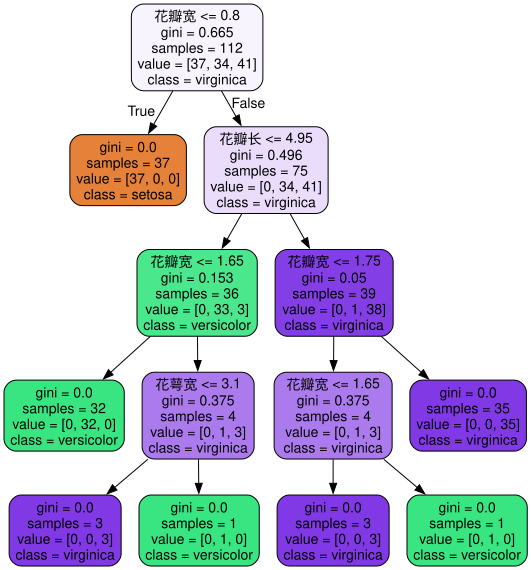

In [7]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

from sklearn.tree import export_graphviz
import graphviz

# decision_tree：需要导出dot文件的决策树模型。
# out_file：指定dot文件的存储路径，如果为None，则不保存dot文件，而是将dot文件内容以str返回。
# filled：是否以颜色进行填充。
# rounded：是否使用圆角矩形。
# feature_names：指定每个特征的名称，默认显示x[0]，x[1],……
# class_names：指定每个节点预测的类别，默认不显示。
dot_data = export_graphviz(tree, out_file=None, filled=True, rounded=True,
                          feature_names=["花萼长", "花萼宽", "花瓣长", "花瓣宽"], 
                           class_names=["setosa", "versicolor", "virginica"])
print(dot_data)

graph = graphviz.Source(dot_data)
graph

In [8]:
export_graphviz(tree, out_file=r"d:\tree.dot", filled=True, rounded=True,
                          feature_names=["花萼长", "花萼宽", "花瓣长", "花瓣宽"], 
                           class_names=["setosa", "versicolor", "virginica"], fontname="Microsoft YaHei")

dot_data = export_graphviz(tree, out_file=None, filled=True, rounded=True,
                          feature_names=["花萼长", "花萼宽", "花瓣长", "花瓣宽"], 
                           class_names=["setosa", "versicolor", "virginica"], fontname="Microsoft YaHei")
graph = graphviz.Source(dot_data)
graph.render("output", format="pdf")

print(tree.feature_importances_)
print(tree.feature_importances_.sum())

[0.         0.02014872 0.39927524 0.58057605]
1.0
